# 03 — CNN + BatchNorm + Dropout on CIFAR-10

**Project:** Progressive CNN Classifier Study
**Stage:** 3 of 6 — Adding Dropout

### Goal
Notebook 02 showed that BatchNorm alone made overfitting *worse* — train accuracy hit 93% while validation accuracy plateaued around 65-70% with rising validation loss after epoch 5. This notebook adds **Dropout** on top of BatchNorm to directly target that overfitting.

### Scoreboard so far
| Notebook | Technique | Test Accuracy | Test Loss |
|---|---|---|---|
| 01 | Baseline | 0.7166 | 0.8821 |
| 02 | + BatchNorm | 0.6807 | 1.5024 |
| 03 (this one) | + BatchNorm + Dropout | 0.7250 | 0.7805 |

### What is Dropout?
During training, Dropout randomly "switches off" a fraction `p` of neurons in a layer on every forward pass (different neurons each batch). This:
- **Prevents co-adaptation** — neurons can't rely on specific other neurons always being present, so the network learns more redundant, generalizable features.
- **Acts like training an ensemble** — each batch effectively trains a slightly different sub-network; at test time all neurons are active (scaled appropriately), approximating an ensemble average.
- **Directly targets the train/val gap** — unlike BatchNorm (which speeds up fitting), Dropout makes fitting *harder* on purpose, which is exactly the brake our BatchNorm model needed.

### What this notebook covers
- Adding Dropout after pooling layers and before the final Dense layer
- Choosing sensible dropout rates (lower in early conv layers, higher near the dense head)
- Comparing train/val gap against Notebook 02's clearly overfit curves

## 1. Imports

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Load and Preprocess CIFAR-10

Identical preprocessing to Notebooks 01 and 02 — keeps the comparison fair.

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Build the CNN + BatchNorm + Dropout

**Changes vs. Notebook 02:**
- `Dropout(0.25)` after each pooling block (lower rate — early features are more fundamental, we don't want to destroy too much signal early)
- `Dropout(0.5)` before the final output layer (higher rate — the dense layer has the most parameters and is most prone to overfitting/memorization)

This is a standard, widely-used pattern: light dropout early, heavier dropout late.

In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

/Users/adityagupta/Desktop/Machine learning/GDenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,210 (481.29 KB)

 Trainable params: 122,890 (480.04 KB)

 Non-trainable params: 320 (1.25 KB)

Note: Dropout adds **zero** trainable parameters — it's a training-time-only behavior (at inference, all neurons are active). Any accuracy change we see is purely from the *regularization effect*, not added model capacity.

## 4. Compile

Same optimizer, loss, and metric as Notebooks 01 and 02.

In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 5. Train

Same 15 epochs, batch size 64, validation data — identical training conditions to isolate Dropout's effect.

In [5]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3526 - loss: 1.8842 - val_accuracy: 0.3764 - val_loss: 1.9105
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4758 - loss: 1.4628 - val_accuracy: 0.4848 - val_loss: 1.5020
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5310 - loss: 1.3189 - val_accuracy: 0.4554 - val_loss: 1.5934
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5700 - loss: 1.2255 - val_accuracy: 0.5441 - val_loss: 1.2708
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5949 - loss: 1.1510 - val_accuracy: 0.6124 - val_loss: 1.0924
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6176 - loss: 1.0977 - val_accuracy: 0.5637 - val_loss: 1.3068
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6365 - loss: 1.0450 - val_accuracy: 0.6459 - val_loss: 1.0231
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6475 - loss: 1.0142 - v

## 6. Save the Model

In [6]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

model.save("models/dropout_cnn.h5")
print("Model saved to models/dropout_cnn.h5")

Model saved to models/dropout_cnn.h5


## 7. Visualize Training Curves

Compare directly against Notebook 02's plots. Expect:
- Train accuracy rising more slowly (Dropout makes fitting the training set harder on purpose)
- A much smaller train/val gap
- Val loss staying flatter instead of climbing after epoch 5

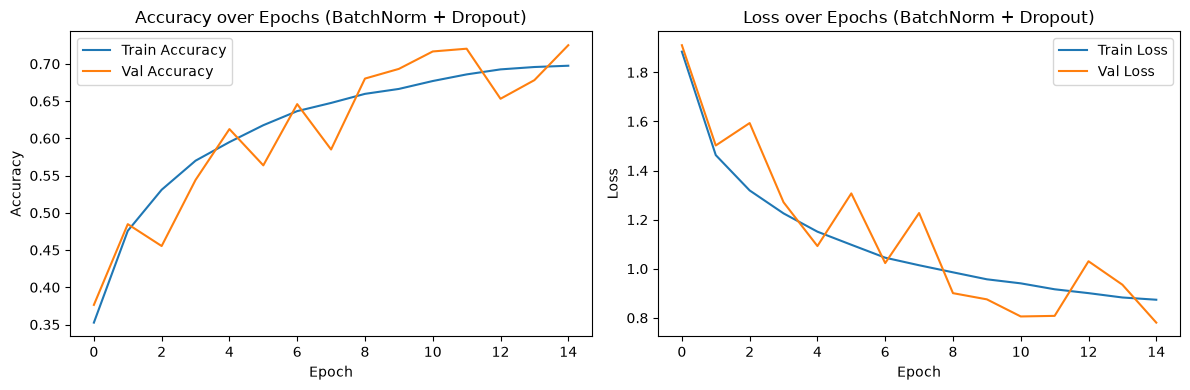

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs (BatchNorm + Dropout)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs (BatchNorm + Dropout)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/dropout_cnn_curves.png")
plt.show()

## 8. Final Evaluation

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7250 - loss: 0.7805
Final Test Accuracy: 0.7250
Final Test Loss: 0.7805


## 9. Direct Comparison vs. Previous Stages

In [9]:
results_table = [
    ("Baseline (01)", 0.7166, 0.8821),
    ("BatchNorm (02)", 0.6807, 1.5024),
    ("BatchNorm + Dropout (03)", test_acc, test_loss),
]

print(f"{'Model':<28}{'Test Accuracy':<18}{'Test Loss':<12}")
for name, acc, loss in results_table:
    print(f"{name:<28}{acc:<18.4f}{loss:<12.4f}")

print(f"\nAccuracy change vs Baseline: {test_acc - 0.7166:+.4f}")
print(f"Accuracy change vs BatchNorm-only: {test_acc - 0.6807:+.4f}")

Model                       Test Accuracy     Test Loss   
Baseline (01)               0.7166            0.8821      
BatchNorm (02)              0.6807            1.5024      
BatchNorm + Dropout (03)    0.7250            0.7805      

Accuracy change vs Baseline: +0.0084
Accuracy change vs BatchNorm-only: +0.0443


## Summary & Next Steps

| Notebook | Technique Added | Test Accuracy |
|---|---|---|
| 01 | None (baseline) | 0.7166 |
| 02 | + Batch Normalization | 0.6807 |
| 03 | + Dropout | 0.7250 |
| 04 | + Data Augmentation | 0.6359 / 0.6680 |
| 05 | + LR Scheduling | 0.7407 |
| 06 | Transfer Learning (MobileNetV2) | 0.8928 |

**Interpretation tip for your report:** the key comparison isn't just the final accuracy number — it's the *shape of the curves*. If Dropout closed the train/val gap and flattened the rising validation loss from Notebook 02, that proves Dropout did its job as a regularizer, even if the final accuracy number is similar to (or slightly below) the baseline. Overfitting control and peak accuracy are related but different goals — this is a subtlety worth explicitly discussing in your report.

**Next:** proceed to `04_data_augmentation.ipynb`, where we add random flips/rotations/shifts to artificially expand the effective size of the training set — another overfitting countermeasure, this time acting on the data rather than the network.